In [2]:
# Import data analysis libraries 
import pandas as pd 
import numpy as np 
 
# Import visualisation libraries 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [3]:
df = pd.read_csv(r"C:\Users\Lenovo ThinkPad\OneDrive\Desktop\project for Github\the secound project\Data\raw\loan_default_dataset_noisy.csv")
df.head(5)

,CustomerID,Age,Gender,Marital_Status,Education,Employment_Type,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Income_Loan_Ratio,Loan_Status
0,1000,59,Male,Single,Not Graduate,Salaried,11082,3363,284.0,120,1.0,Semiurban,0.508627,Y
1,1001,49,NaN,Married,Graduate,Salaried,10822,3524,164.0,360,0.0,Semiurban,0.874756,Y
2,1002,35,Male,Married,Graduate,Salaried,3986,3786,414.0,240,1.0,Semiurban,0.187729,N
3,1003,63,Male,Single,Not Graduate,Salaried,10526,23,139.0,300,1.0,Rural,0.758921,Y
4,1004,28,Female,Married,Graduate,Salaried,9918,3003,257.0,240,0.0,Urban,0.502763,N


In [ ]:
# Check data types and missing values 
df.info() 
# Summary statistics for numerical columns 
df.describe() 


<class 'pandas.DataFrame'>
RangeIndex: 2100 entries, 0 to 2099
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         2100 non-null   int64  
 1   Age                2100 non-null   int64  
 2   Gender             1995 non-null   str    
 3   Marital_Status     1993 non-null   str    
 4   Education          2100 non-null   str    
 5   Employment_Type    2100 non-null   str    
 6   ApplicantIncome    2100 non-null   int64  
 7   CoapplicantIncome  2100 non-null   int64  
 8   LoanAmount         1994 non-null   float64
 9   Loan_Amount_Term   2100 non-null   int64  
 10  Credit_History     1993 non-null   float64
 11  Property_Area      2100 non-null   str    
 12  Income_Loan_Ratio  2100 non-null   float64
 13  Loan_Status        2100 non-null   str    
dtypes: float64(3), int64(5), str(6)
memory usage: 229.8 KB


,CustomerID,Age,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Income_Loan_Ratio
count,2100.000000,2100.000000,2100.000000,2100.000000,1994.000000,2100.000000,1993.000000,2100.000000
mean,2001.513810,42.670000,8290.765238,4049.764762,270.344534,240.571429,0.792775,0.640285
std,578.359094,12.603574,3912.710716,2288.544407,128.411200,85.535374,0.405420,0.547168
min,1000.000000,21.000000,1512.000000,2.000000,50.000000,120.000000,0.000000,0.047368
25%,1499.750000,32.000000,4910.750000,2067.250000,158.250000,180.000000,1.000000,0.297800
50%,2002.500000,43.000000,8367.500000,4050.500000,271.000000,240.000000,1.000000,0.457574
75%,2503.250000,54.000000,11666.000000,6001.250000,379.000000,300.000000,1.000000,0.772765
max,2999.000000,64.000000,14999.000000,7999.000000,499.000000,360.000000,1.000000,4.034510


In [6]:
# Count missing values per column 
df.isnull().sum() 

 

#Take Screenshot: 5. Count missing Values

CustomerID             0
Age                    0
Gender               105
Marital_Status       107
Education              0
Employment_Type        0
ApplicantIncome        0
CoapplicantIncome      0
LoanAmount           106
Loan_Amount_Term       0
Credit_History       107
Property_Area          0
Income_Loan_Ratio      0
Loan_Status            0
dtype: int64

In [7]:
# Count duplicate rows 
df.duplicated().sum() 

np.int64(100)

In [8]:
# Fill numerical missing values with median 
df["LoanAmount"] = df["LoanAmount"].fillna(df["LoanAmount"].median()) 
 
# Fill categorical missing values with mode 
df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0]) 
df["Marital_Status"] = df["Marital_Status"].fillna(df["Marital_Status"].mode()[0]) 
df["Credit_History"] = df["Credit_History"].fillna(df["Credit_History"].mode()[0]) 

In [9]:
# Fix column names (remove spaces) 
df.columns = df.columns.str.strip() 
 
# Identify text columns 
text_columns = df.select_dtypes(include=["object", "string"]).columns 
 
# Standardise text (lowercase + remove spaces) 
for col in text_columns: 
    df[col] = df[col].apply(lambda x: x.strip().lower() if isinstance(x, str) else x) 
 
# Convert selected columns to title case for readability 
cols_to_title = ["Gender", "Marital_Status", "Education", "Employment_Type", "Property_Area"] 
 
for col in cols_to_title: 
    if col in df.columns: 
        df[col] = df[col].apply(lambda x: x.title() if isinstance(x, str) else x) 

 

In [10]:
# Check values before mapping 
print(df["Loan_Status"].unique()) 
 
# Convert to numeric (after cleaning → values are lowercase) 
df["Loan_Status"] = df["Loan_Status"].map({"y": 1, "n": 0}) 
 
# Verify conversion 
df["Loan_Status"].value_counts() 

 

#Take Screenshot: 11. Conver Loan Status to Numeric

<StringArray>
['y', 'n']
Length: 2, dtype: str


Loan_Status
1    1094
0    1006
Name: count, dtype: int64

In [12]:
# Create total income 
df["Total_Income"] = df["ApplicantIncome"] + df["CoapplicantIncome"] 
 
# Create loan-to-income ratio 
df["Loan_Income_Ratio"] = df["LoanAmount"] / df["Total_Income"] 

 


In [13]:
# Preview cleaned dataset 
df.head() 

,CustomerID,Age,Gender,Marital_Status,Education,Employment_Type,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Income_Loan_Ratio,Loan_Status,Total_Income,Loan_Income_Ratio
0,1000,59,Male,Single,Not Graduate,Salaried,11082,3363,284.0,120,1.0,Semiurban,0.508627,1,14445,0.019661
1,1001,49,Female,Married,Graduate,Salaried,10822,3524,164.0,360,0.0,Semiurban,0.874756,1,14346,0.011432
2,1002,35,Male,Married,Graduate,Salaried,3986,3786,414.0,240,1.0,Semiurban,0.187729,0,7772,0.053268
3,1003,63,Male,Single,Not Graduate,Salaried,10526,23,139.0,300,1.0,Rural,0.758921,1,10549,0.013177
4,1004,28,Female,Married,Graduate,Salaried,9918,3003,257.0,240,0.0,Urban,0.502763,0,12921,0.019890


In [14]:
 

# Final check of cleaned data 

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2100 entries, 0 to 2099
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         2100 non-null   int64  
 1   Age                2100 non-null   int64  
 2   Gender             2100 non-null   str    
 3   Marital_Status     2100 non-null   str    
 4   Education          2100 non-null   str    
 5   Employment_Type    2100 non-null   str    
 6   ApplicantIncome    2100 non-null   int64  
 7   CoapplicantIncome  2100 non-null   int64  
 8   LoanAmount         2100 non-null   float64
 9   Loan_Amount_Term   2100 non-null   int64  
 10  Credit_History     2100 non-null   float64
 11  Property_Area      2100 non-null   str    
 12  Income_Loan_Ratio  2100 non-null   float64
 13  Loan_Status        2100 non-null   int64  
 14  Total_Income       2100 non-null   int64  
 15  Loan_Income_Ratio  2100 non-null   float64
dtypes: float64(4), int64(7), str(5)
mem

In [16]:
import os

os.makedirs("../data/cleaned_data", exist_ok=True)

In [17]:
df.to_csv("../data/cleaned_data/loan_default_dataset_cleaned.csv", index=False) 

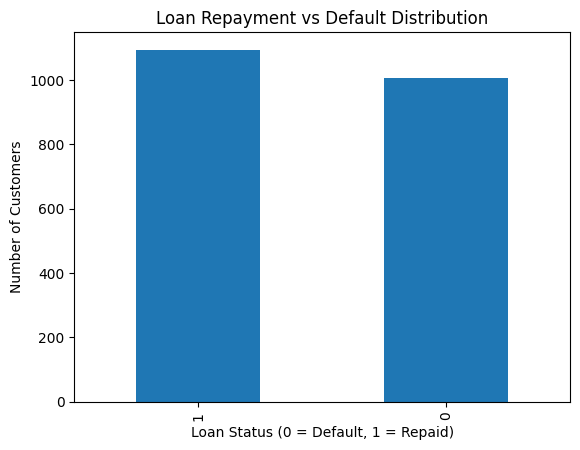

In [18]:
df["Loan_Status"].value_counts().plot(kind="bar") 
 
plt.title("Loan Repayment vs Default Distribution") 
plt.xlabel("Loan Status (0 = Default, 1 = Repaid)") 
plt.ylabel("Number of Customers") 
 
# plt.savefig("../images/09_default_distribution.png") 
plt.show() 

 

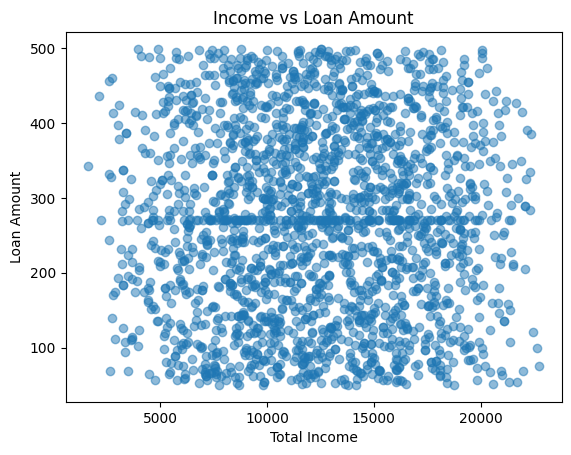

In [19]:
plt.scatter(df["Total_Income"], df["LoanAmount"], alpha=0.5) 
 
plt.title("Income vs Loan Amount") 
plt.xlabel("Total Income") 
plt.ylabel("Loan Amount") 
 
#plt.savefig("../images/10_income_vs_loan.png") 
plt.show() 

 

#Take Screenshot: 16. Income vs Loan Amount- Chart + Code 

#Take Screenshot: 16. Income vs Loan Amount- Chart Only 

 

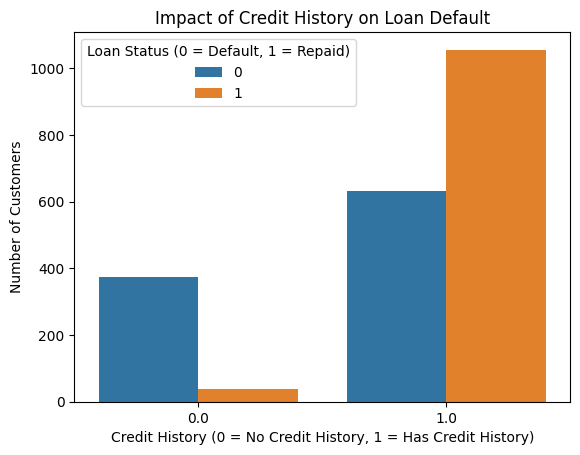

In [20]:
sns.countplot(x="Credit_History", hue="Loan_Status", data=df) 

 

plt.title("Impact of Credit History on Loan Default") 

plt.xlabel("Credit History (0 = No Credit History, 1 = Has Credit History)") 

plt.ylabel("Number of Customers") 

 

plt.legend(title="Loan Status (0 = Default, 1 = Repaid)") 

 

# plt.savefig("../images/11_credit_vs_default.png") 

plt.show() 

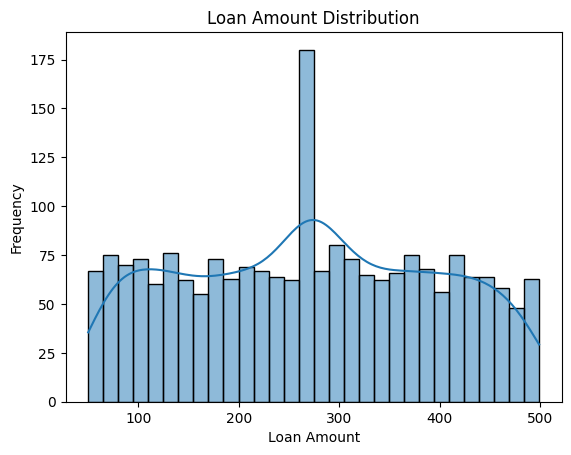

In [21]:
sns.histplot(df["LoanAmount"], bins=30, kde=True) 
 
plt.title("Loan Amount Distribution") 
plt.xlabel("Loan Amount") 
plt.ylabel("Frequency") 
 
#plt.fig("../images/12_loan_distribution.png") 
plt.show() 

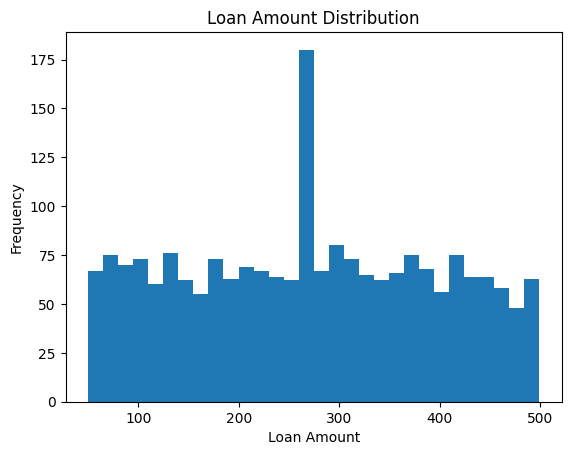

In [22]:
# OR 

#Alternative :1 

# Using Matplotlib only for Chart 4 (without KDE) 

 

# Chart 4 — Loan Amount Distribution (Matplotlib only) 

plt.hist(df["LoanAmount"], bins=30) 

 

plt.title("Loan Amount Distribution") 

plt.xlabel("Loan Amount") 

plt.ylabel("Frequency") 

 

# plt.savefig("../images/12_loan_distribution.png") 

plt.show() 

 

In [23]:
 

# OR 

#Alternative :2 

# If you still want a KDE-like curve (optional) 

# Seaborn automatically adds the smooth curve (kde=True). 

# To replicate that in pure Matplotlib, you can use SciPy: 

 

import matplotlib.pyplot as plt 

from scipy.stats import gaussian_kde 

import numpy as np 

 

data = df["LoanAmount"].dropna()

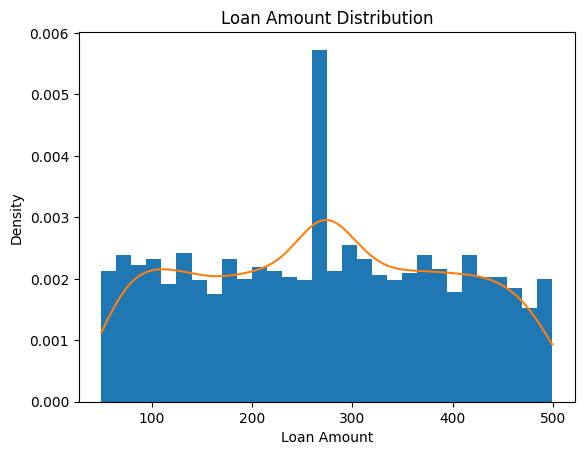

In [24]:
# Histogram 

plt.hist(data, bins=30, density=True) 

 

# KDE curve 

kde = gaussian_kde(data) 

x_vals = np.linspace(data.min(), data.max(), 500) 

plt.plot(x_vals, kde(x_vals)) 

 

plt.title("Loan Amount Distribution") 

plt.xlabel("Loan Amount") 

plt.ylabel("Density") 

 

# plt.savefig("../images/12_loan_distribution.png") 

plt.show() 

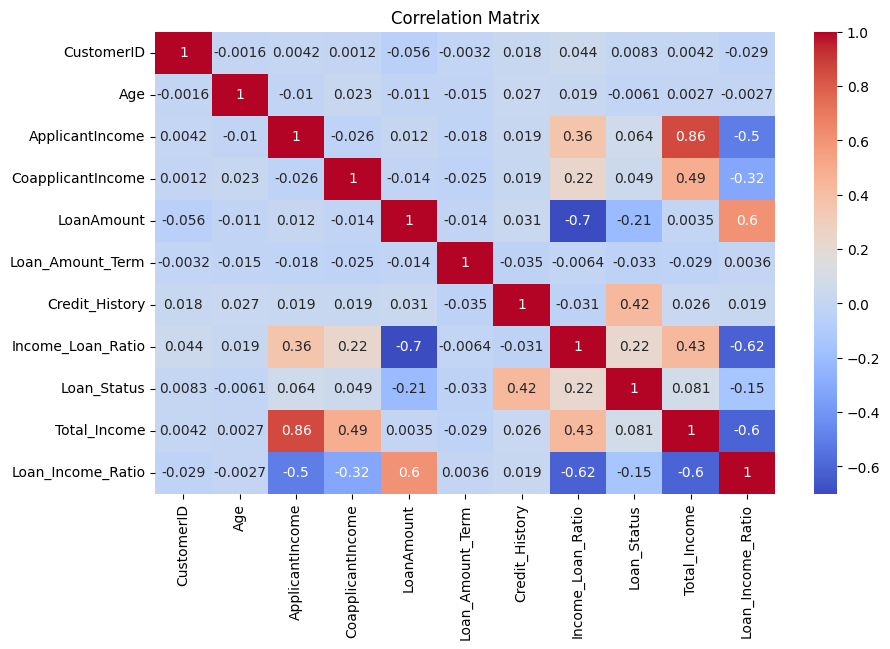

In [ ]:
plt.figure(figsize=(10,6)) 
 
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm") 
 
plt.title("Correlation Matrix") 
 
# plt.savefig("../images/13_correlation_matrix.png") 
plt.show() 


 

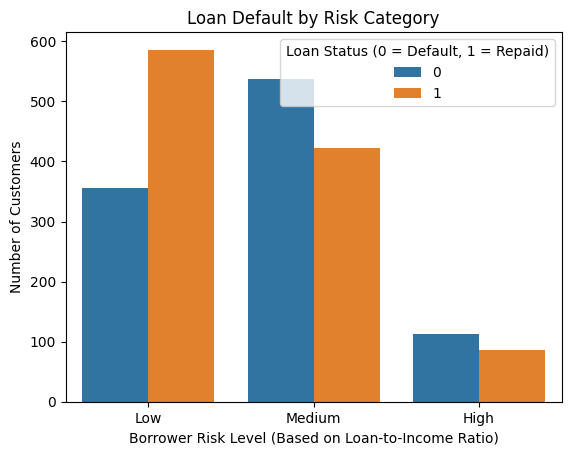

In [27]:
df["Risk_Level"] = pd.cut( 
    df["Loan_Income_Ratio"], 
    bins=[0, 0.02, 0.05, 1], 
    labels=["Low", "Medium", "High"] 
) 


sns.countplot(x="Risk_Level", hue="Loan_Status", data=df) 

 

plt.title("Loan Default by Risk Category") 

plt.xlabel("Borrower Risk Level (Based on Loan-to-Income Ratio)") 

plt.ylabel("Number of Customers") 

 

plt.legend(title="Loan Status (0 = Default, 1 = Repaid)") 

 

# plt.savefig("../images/14_risk_segmentation.png") 

plt.show() 

In [28]:
df.to_csv("../data/cleaned_data/loan_default_dataset_cleaned.csv", index=False) 

In [30]:
import os
print(os.getcwd())

c:\Users\Lenovo ThinkPad\OneDrive\Desktop\project for Github\the secound project
